# Multivariate Hypergeometric Distribution

`MultivariateHypergeometric(m, n)` generalizes the hypergeometric distribution to more than two types. A collection holds `m[i]` items of type `i`, draw `n` of them all at once, **without replacement**. Each draw is a vector of counts, one per type, that sums to `n`.

In [21]:
from symbulate import *

## Draw a value

Each draw is a vector of counts, one per type, summing to `n`. Here the collection has 10 items of the first type, 8 of the second, and 6 of the third, and we draw 6.

In [22]:
MultivariateHypergeometric(m=[10, 8, 6], n=6).draw()

(2, 3, 1)

## Simulate

Every simulated value is a vector of counts summing to `n`.

In [23]:
MultivariateHypergeometric(m=[10, 8, 6], n=6).sim(1000)

0,"(1, 3, 2)"
1,"(2, 3, 1)"
2,"(1, 3, 2)"
3,"(2, 2, 2)"
4,"(3, 1, 2)"
5,"(2, 2, 2)"
6,"(2, 3, 1)"
7,"(4, 1, 1)"
8,"(3, 2, 1)"
...,...
999,"(2, 4, 0)"


## Mean, variance, and standard deviation

These return one value per type. `mean()` is the expected count of each type, `n * m[i] / sum(m)` -- the share of the collection each type makes up, scaled to the `n` items drawn.

In [24]:
X = MultivariateHypergeometric(m=[10, 8, 6], n=6)
X.mean(), X.var(), X.sd()

((2.5, 2.0, 1.5),
 (1.141304347826087, 1.0434782608695654, 0.8804347826086957),
 (1.0683184674178796, 1.0215078369104984, 0.9383148632568364))

## Covariance matrix

`cov()` returns the full covariance matrix. Its diagonal holds the per-type variances.

In [25]:
X.cov()

array([[ 1.14130435, -0.65217391, -0.48913043],
       [-0.65217391,  1.04347826, -0.39130435],
       [-0.48913043, -0.39130435,  0.88043478]])

## Correlation matrix

`corr()` rescales the covariance into correlations between -1 and 1.

In [26]:
X.corr()

array([[ 1.        , -0.5976143 , -0.48795004],
       [-0.5976143 ,  1.        , -0.40824829],
       [-0.48795004, -0.40824829,  1.        ]])

## Evaluate the probability of an outcome

The probability of drawing a specific set of counts (which must sum to `n`).

In [27]:
MultivariateHypergeometric(m=[10, 8, 6], n=6).pdf([2, 2, 2])

np.float64(0.14042022051175373)

## Relationship: each count is marginally hypergeometric

Focusing on a single type and lumping all the others together is an ordinary two-type hypergeometric draw. Here the first count of `MultivariateHypergeometric([10, 8, 6], 6)` is `Hypergeometric(n=6, N0=14, N1=10)` (10 items of that type, 14 of the rest, 6 drawn).

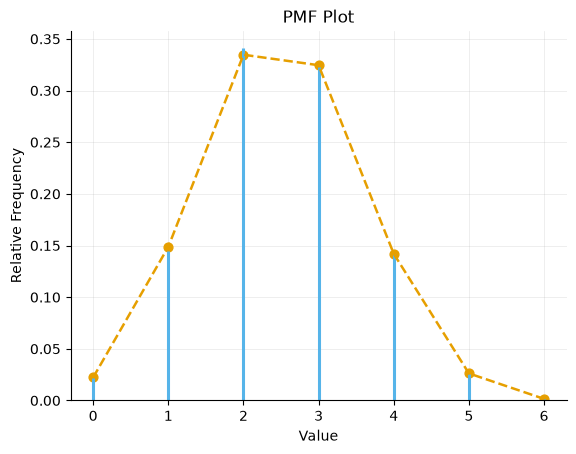

In [28]:
A, B, C = RV(MultivariateHypergeometric(m=[10, 8, 6], n=6))
A.sim(10000).plot()
Hypergeometric(n=6, N0=14, N1=10).plot()

## Relationship: with a large collection it approaches the Multinomial

The `Multinomial` is the *with-replacement* version of this. When the collection is large relative to the number drawn, removing a few items barely changes the proportions, so drawing without replacement is nearly the same as with replacement.

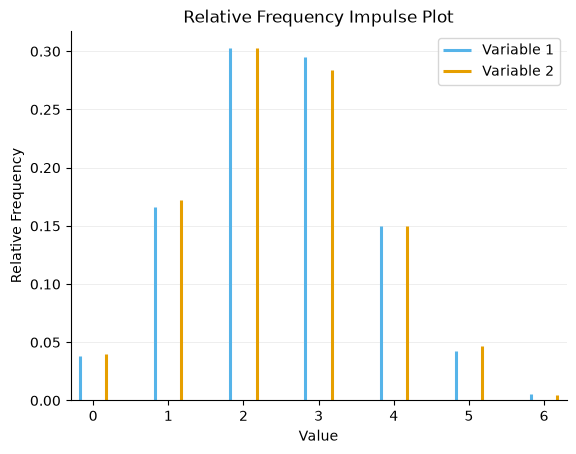

In [29]:
P, Q, R = RV(MultivariateHypergeometric(m=[100, 80, 60], n=6))
S, T, U = RV(Multinomial(n=6, p=[100 / 240, 80 / 240, 60 / 240]))
P.sim(10000).plot()
S.sim(10000).plot()